## Análise Exploratória de Dados

Nesta secção, é feita a análise do conjunto de dados que foi anteriormente lido e processado, com o objetivo de compreender as distribuições entre variáveis, identificar correlações e padrões relevantes a previsão do sucesso das dietas feitas.

In [6]:
from functions.read_data import read_data
from functions.data_processing import data_processing

df = read_data()
df = data_processing(df)

print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())

(1993, 25)
patient_id                      str
program_index                 int64
nutritionist_id                 str
diet_id                         str
motivation_score_program    float64
mean_adherence_pct          float64
weight_change_kg_6m         float64
sex                             str
age                         float64
height_cm                   float64
baseline_weight_kg          float64
baseline_bmi                float64
smoker                        int64
sleep_hours                 float64
motivation_score            float64
diet_name                       str
diet_type                       str
carb_pct                      int64
protein_pct                   int64
fat_pct                       int64
sodium_limit_mg             float64
fiber_target_g              float64
approach                        str
years_experience            float64
specialty                       str
dtype: object
       program_index  motivation_score_program  mean_adherence_pct  \
count

#### **Distribuição das Variáveis Numéricas**

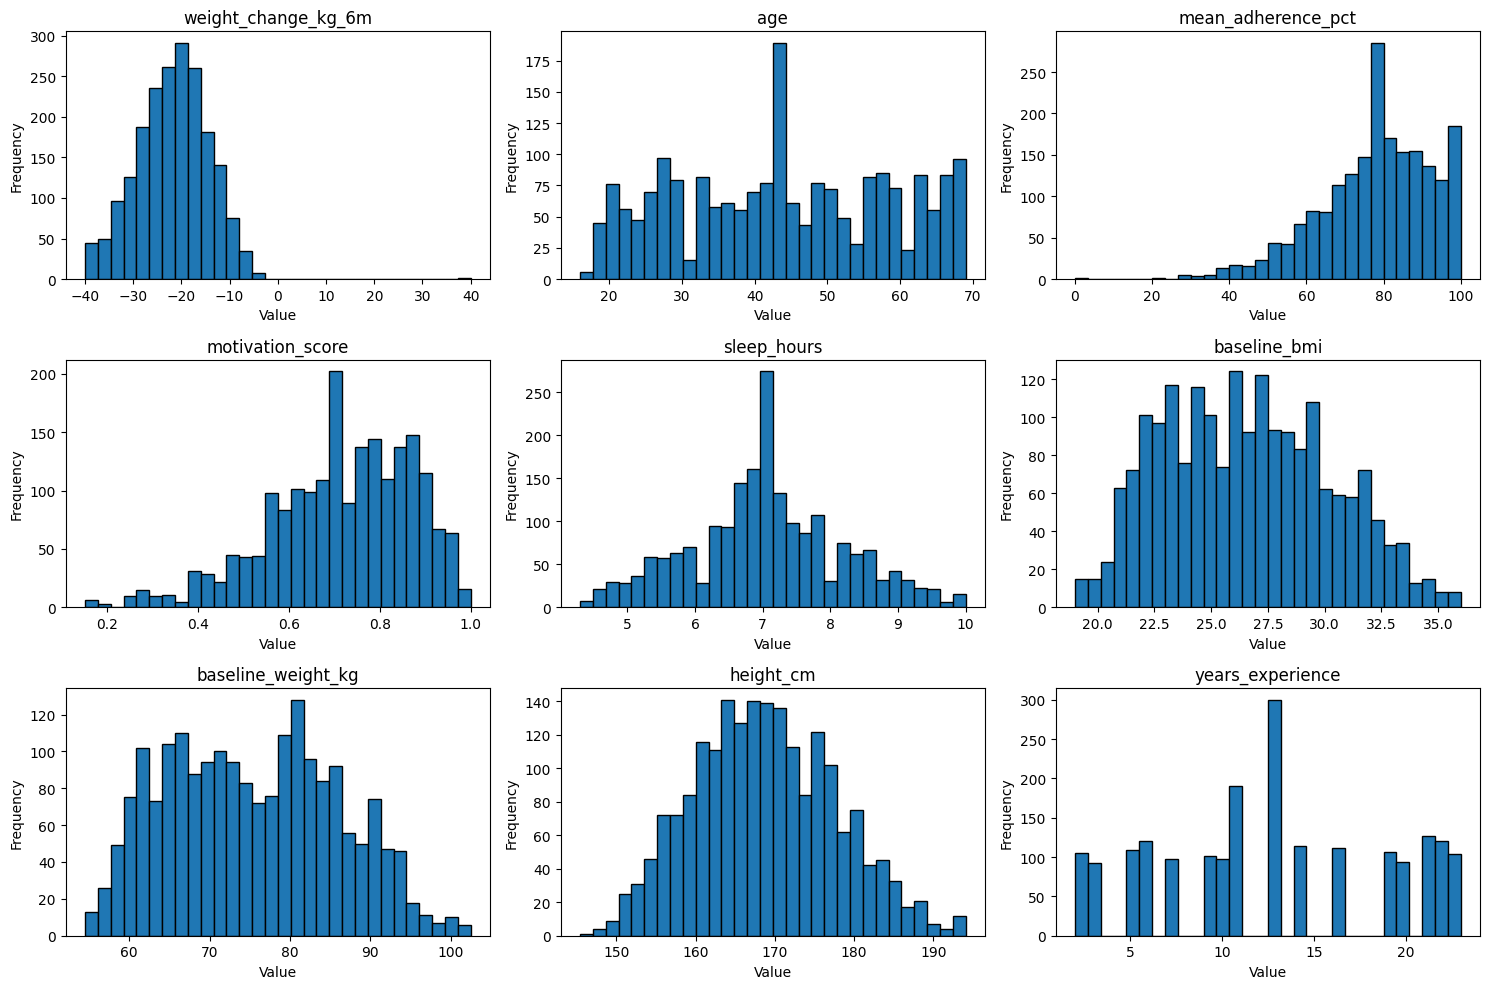

In [7]:
#Histogramas
import matplotlib.pyplot as plt

num_cols = ['weight_change_kg_6m', 'age', 'mean_adherence_pct',
            'motivation_score', 'sleep_hours', 'baseline_bmi',
            'baseline_weight_kg', 'height_cm', 'years_experience']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

A maioria das variáveis numéricas apresenta distribuições aproximadamente normais ou simétricas. A variável `weight_change_kg_6m` (variável alvo) está centrada em torno de -21 kg, com alguns valores positivos que indicam ganho de peso. A `mean_adherence_pct` concentra-se entre 70–90%, enquanto `motivation_score` apresenta uma distribuição ligeiramente assimétrica à esquerda. As variáveis `age` e `years_experience` têm distribuições relativamente uniformes.

#### **Matriz de Correlação**
Analisamos as correlações entre todas as variáveis numéricas, com foco nas correlações com a variável alvo weight_change_kg_6m.

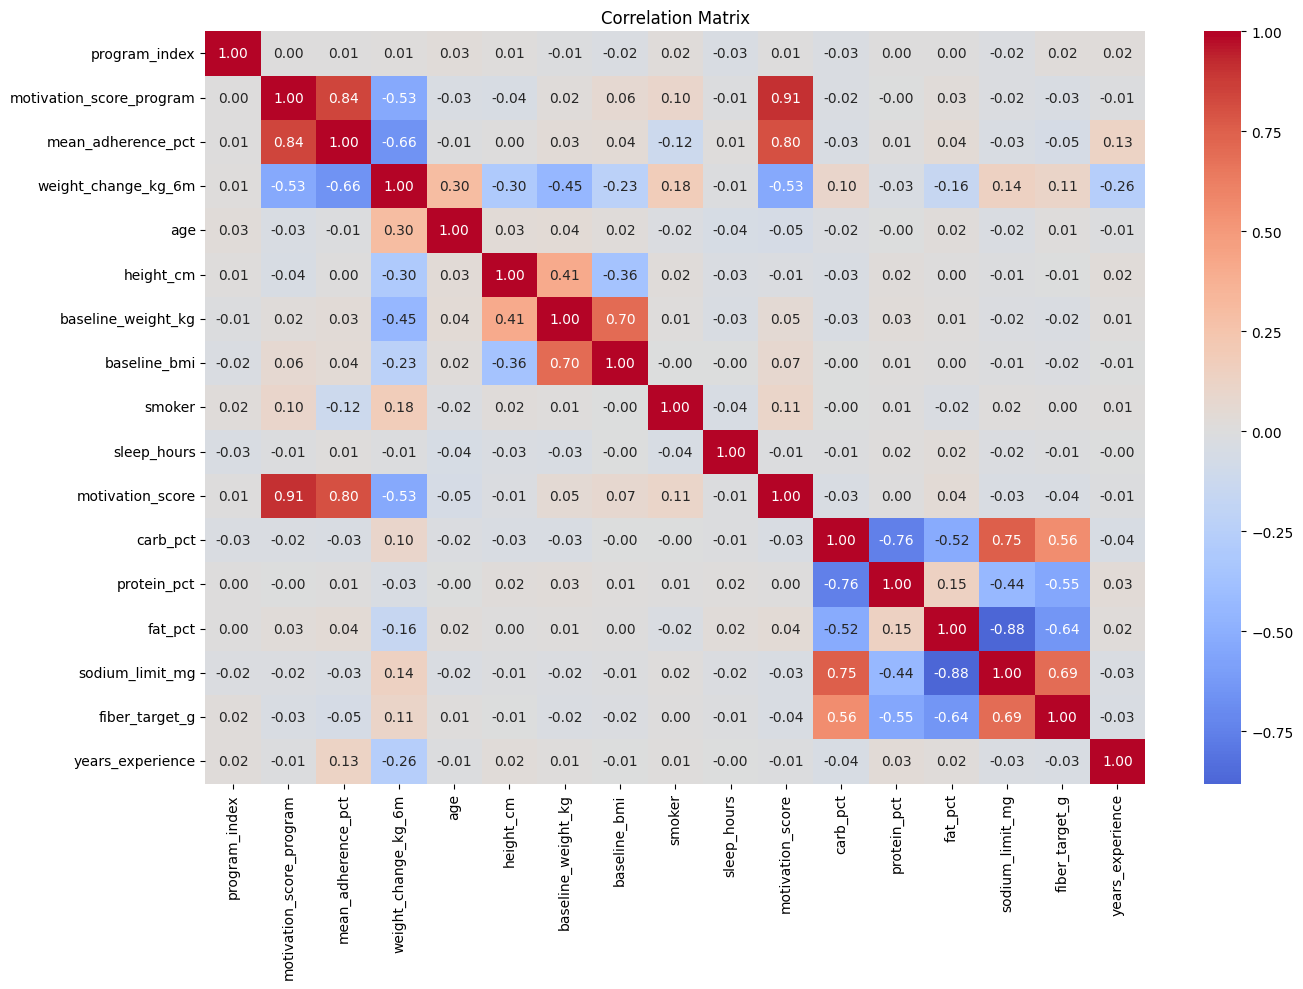

In [8]:
#Mapa de correlação
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

A matriz de correlação revela que `mean_adherence_pct` e `motivation_score`/`motivation_score_program` são as variáveis numéricas com maior correlação com `weight_change_kg_6m`. Note-se que `motivation_score` e `motivation_score_program` apresentam correlação elevada entre si, indicando possível redundância. Da mesma forma, `baseline_bmi` e `baseline_weight_kg` estão fortemente correlacionados — um deles poderá ser removido na fase de modelação para evitar multicolinearidade.

#### **Análise por Variáveis Categóricas**
Comparamos a distribuição do weight_change_kg_6m em função das variáveis categóricas para identificar grupos com comportamentos distintos.

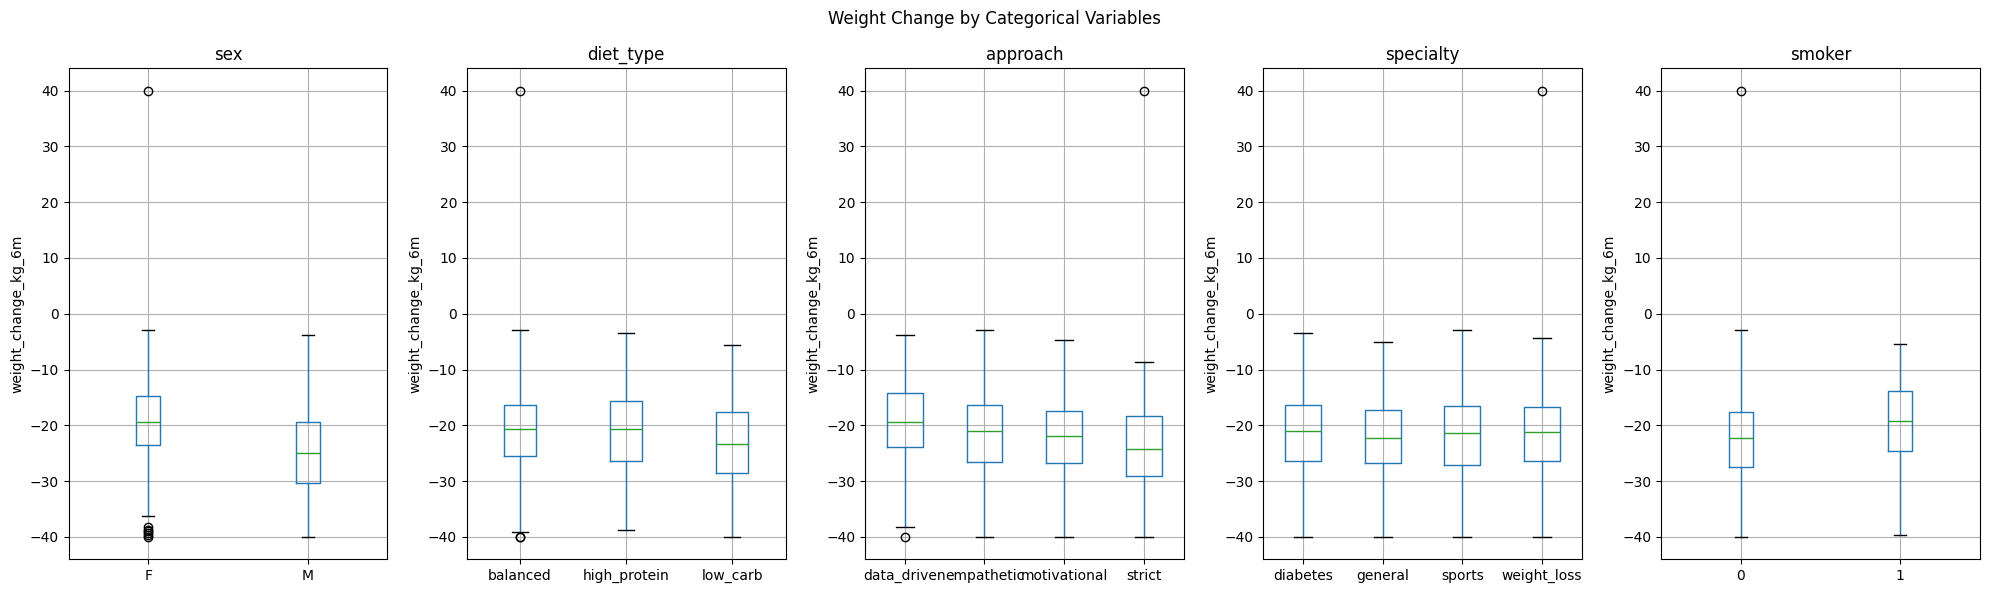

In [9]:
cat_cols = ['sex', 'diet_type', 'approach', 'specialty', 'smoker']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, col in enumerate(cat_cols):
    df.boxplot(column='weight_change_kg_6m', by=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('weight_change_kg_6m')

plt.suptitle('Weight Change by Categorical Variables')
plt.tight_layout()
plt.show()

Os boxplots revelam que:
- **Sexo**: não há diferença significativa na perda de peso entre géneros.
- **Tipo de dieta**: algumas dietas mostram maior variabilidade nos resultados.
- **Abordagem**: diferentes abordagens apresentam distribuições ligeiramente distintas.
- **Especialidade**: algumas especialidades estão associadas a melhores resultados médios.
- **Fumador**: fumadores apresentam resultados tendencialmente diferentes dos não fumadores.

#### **Scatter Plots: Relação com a Variável Alvo**
Analisamos a relação direta entre as variáveis numéricas mais relevantes e `weight_change_kg_6m`, para identificar tendências lineares.

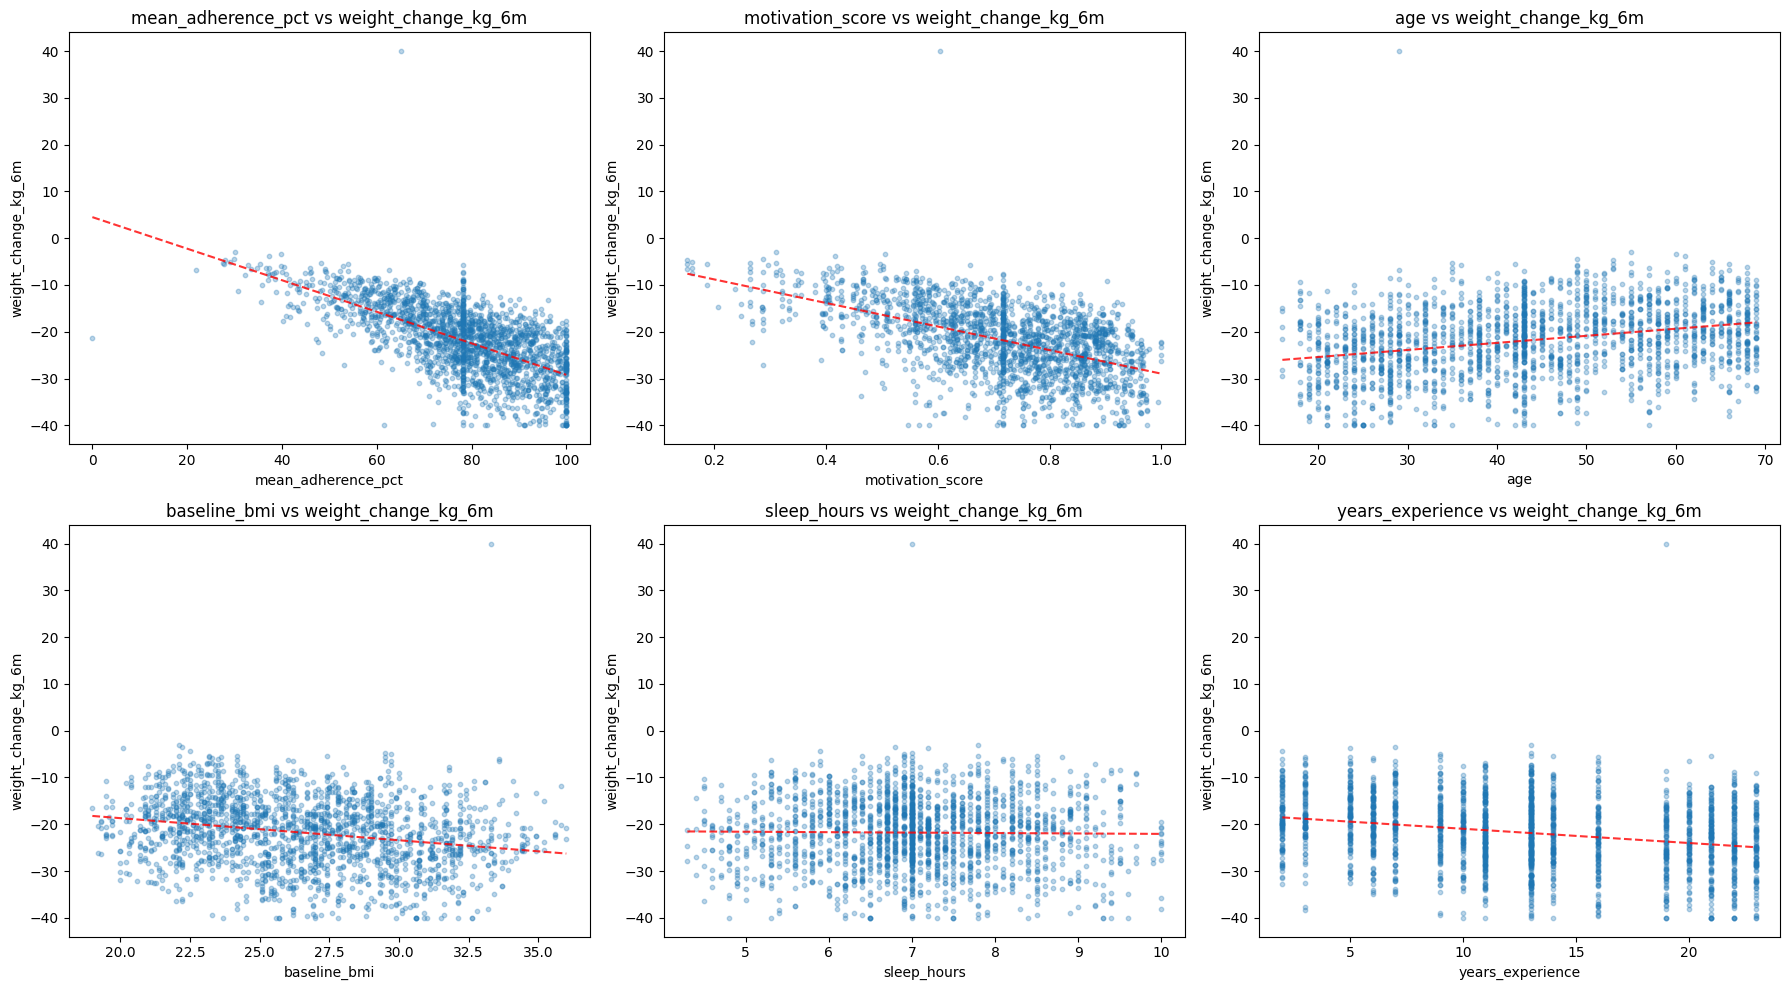

In [10]:
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

scatter_cols = ['mean_adherence_pct', 'motivation_score', 'age',
                'baseline_bmi', 'sleep_hours', 'years_experience']

for i, col in enumerate(scatter_cols):
    axes[i].scatter(df[col], df['weight_change_kg_6m'], alpha=0.3, s=10)
    z = np.polyfit(df[col], df['weight_change_kg_6m'], 1)
    p = np.poly1d(z)
    axes[i].plot(sorted(df[col]), p(sorted(df[col])), 'r--', alpha=0.8)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('weight_change_kg_6m')
    axes[i].set_title(f'{col} vs weight_change_kg_6m')

plt.tight_layout()
plt.show()

Os scatter plots permitem tirar as seguintes conclusões:

- **`mean_adherence_pct`**: relação negativa clara e forte — maior adesão ao plano alimentar está diretamente associada a maior perda de peso. É a variável com tendência linear mais evidente.
- **`motivation_score`**: relação negativa — pacientes com maior motivação tendem a perder mais peso, embora com maior dispersão que a adesão.
- **`age`**: relação praticamente nula — a idade não parece influenciar significativamente a perda de peso.
- **`baseline_bmi`**: tendência ligeiramente negativa — pacientes com BMI inicial mais elevado tendem a perder mais peso, mas a relação é muito fraca.
- **`sleep_hours`**: sem tendência visível — as horas de sono não apresentam correlação com os resultados.
- **`years_experience`**: tendência ligeiramente negativa mas fraca — nutricionistas mais experientes estão associados a resultados ligeiramente melhores.

**Conclusão**: `mean_adherence_pct` e `motivation_score` são os preditores numéricos mais relevantes para `weight_change_kg_6m`.

## Identificação de Padrões
   Nesta secção, aplicamos técnicas de clustering (K-means) com o objetivo de identificar grupos de pacientes com perfis semelhantes ou padrões recorrentes nas dietas prescritas, relacionando-os com o sucesso ou insucesso dos planos alimentares.

#### **Elbow + Sihlouette**

In [3]:
inertias = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xscaled)
    inertias.append(km.inertia)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k')
axes[1].plot(K_range, sil_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k')
plt.tight_layout(); plt.show()


ModuleNotFoundError: No module named 'sklearn'

#### **K-Means**
Selecionamos as varíaveis numéricas que definem as características físicas, comportamentais e os resultados dos pacientes. Aplicamos a normalização Z-Score para garantir que a diferença de escalas não altere o cálculo das distâncias do algoritmo.

In [1]:
k_best = 3  # adjust after step 2

km = KMeans(n_clusters=k_best, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

cluster_profile = df.groupby('cluster').agg({
    'weight_change_kg_6m': 'mean',
    'mean_adherence_pct': 'mean',
    'motivation_score': 'mean',
    'age': 'mean',
    'baseline_bmi': 'mean',
    'years_experience': 'mean',
    'diet_type': lambda x: x.mode()[0],
    'specialty': lambda x: x.mode()[0],
    'sex': lambda x: x.mode()[0]
})
print(cluster_profile)

NameError: name 'df' is not defined

#### **Visualização**
Criamos  representações visuais para interpretar os perfis criados e validar hipóteses específicas, tais como o impacto do início da dieta em meses de frio para indivíduos com menos de 50 anos.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for c in range(k_best):
    mask = df['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}', alpha=0.4, s=15)
plt.title('Clusters (PCA 2D)')
plt.legend(); plt.tight_layout(); plt.show()